In [3]:
import torch
import torchvision
import warnings
import os
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader
from diffusers import DDPMScheduler, UNet2DModel
from matplotlib import pyplot as plt

warnings.filterwarnings("ignore")
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

print("Torch Version:", torch.__version__)
print("CUDA Availablility:", torch.cuda.is_available())
print("GPU Name:", torch.cuda.get_device_name(0))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Torch Version: 2.5.1+cu121
CUDA Availablility: True
GPU Name: NVIDIA RTX 2000 Ada Generation Laptop GPU
Using device: cuda


In [6]:
# Data
dataset = torchvision.datasets.MNIST(root="mnist/", train=True, download=True, transform=torchvision.transforms.ToTensor())
print(dataset)

Dataset MNIST
    Number of datapoints: 60000
    Root location: mnist/
    Split: Train
    StandardTransform
Transform: ToTensor()


Input shape: torch.Size([8, 1, 28, 28])
Labels: tensor([5, 7, 1, 0, 1, 1, 4, 8])


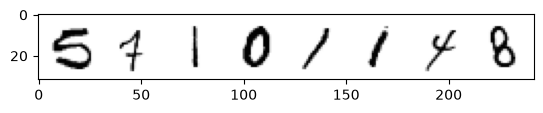

In [ ]:
# Dataloader
train_dataloader = DataLoader(dataset=dataset, batch_size=8, shuffle=True)

x, y = next(iter(train_dataloader))
print('Input shape:', x.shape)
print('Labels:', y)
plt.imshow(torchvision.utils.make_grid(x)[0], cmap='Greys')

In [10]:
# Corruption
def corrupt(x, amount):
    """
        Corrupt the input `x` by mixing it with noise according to `amount`
             x: (batch_size, channel, height, width)
         noise: (batch_size, channel, height, width)
        amount: (batch_size)
    """
    noise = torch.rand_like(x)
    amount = amount.view(-1, 1, 1, 1)           # amount: (batch_size) -> (batch_size, 1, 1, 1)
    return x * (1 - amount) + noise * amount    # output: (batch_size, channel, height, width) = (8, 1, 28, 28)

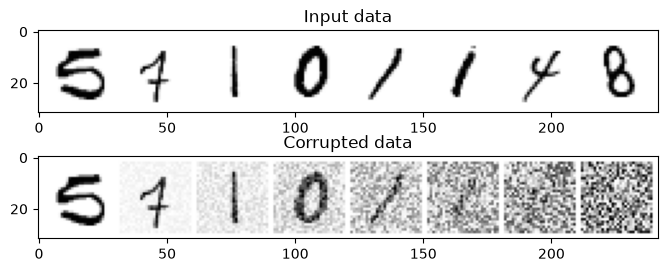

In [12]:
# Plotting the input data
fig, axs = plt.subplots(2, 1, figsize=(8, 3))
axs[0].set_title('Input data')
axs[0].imshow(torchvision.utils.make_grid(x)[0], cmap='Greys')

# Adding noise
amount = torch.linspace(0, 1, x.shape[0]) # Left to right -> more corruption
noised_x = corrupt(x, amount)

# Plotting the noised version
axs[1].set_title('Corrupted data')
axs[1].imshow(torchvision.utils.make_grid(noised_x)[0], cmap='Greys')

In [20]:
# UNet
class UNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super().__init__()

        self.down_layers = torch.nn.ModuleList([ 
            nn.Conv2d(in_channels, 32, kernel_size=5, padding=2),
            nn.Conv2d(32, 64, kernel_size=5, padding=2),
            nn.Conv2d(64, 64, kernel_size=5, padding=2),
        ])

        self.up_layers = torch.nn.ModuleList([
            nn.Conv2d(64, 64, kernel_size=5, padding=2),
            nn.Conv2d(64, 32, kernel_size=5, padding=2),
            nn.Conv2d(32, out_channels, kernel_size=5, padding=2), 
        ])

        self.act = nn.SiLU()        # activation function: SiLU(x) = x ⋅ σ(x), where σ(x) is the sigmoid function
        self.downscale = nn.MaxPool2d(2)
        self.upscale = nn.Upsample(scale_factor=2)

    def forward(self, x):
        h = []

        for i, l in enumerate(self.down_layers):
            x = self.act(l(x)) 
            if i < 2: 
                h.append(x) 
                x = self.downscale(x) 
              
        for i, l in enumerate(self.up_layers):
            if i > 0: 
                x = self.upscale(x) 
                x += h.pop() 
            x = self.act(l(x)) 
            
        return x

In [21]:
net = UNet()
x = torch.rand(8, 1, 28, 28)
print("Output shape of UNet:", net(x).shape)

param_num = sum([p.numel() for p in net.parameters()])
print("Number of parameter in UNet:", param_num)

Output shape of UNet: torch.Size([8, 1, 28, 28])
Number of parameter in UNet: 309057


In [22]:
# Training the network
batch_size = 128
train_dataloader = DataLoader(dataset=dataset, batch_size=batch_size, shuffle=True)

model = UNet().to(device)
n_epochs = 30
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3) 
losses = []

# Training loop
for epoch in range(n_epochs):

    for image, label in train_dataloader:

        image = image.to(device) 
        noise_amount = torch.rand(image.shape[0]).to(device)
        noisy_image = corrupt(image, noise_amount) 

        # Get the model prediction
        pred = model(noisy_image)

        # Calculate the loss
        loss = loss_fn(pred, image)

        # Backpropagation and update the parameters
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Store the loss for later
        losses.append(loss.item())

    # Print out the average of the loss values for this epoch
    avg_loss = sum(losses[-len(train_dataloader):])/len(train_dataloader)
    print(f'>>> Average loss for epoch {epoch+1}: {avg_loss:05f}')

>>> Average loss for epoch 1: 0.026581
>>> Average loss for epoch 2: 0.020247
>>> Average loss for epoch 3: 0.018460
>>> Average loss for epoch 4: 0.017601
>>> Average loss for epoch 5: 0.017114
>>> Average loss for epoch 6: 0.016891
>>> Average loss for epoch 7: 0.016389
>>> Average loss for epoch 8: 0.016451
>>> Average loss for epoch 9: 0.015883
>>> Average loss for epoch 10: 0.015870
>>> Average loss for epoch 11: 0.015831
>>> Average loss for epoch 12: 0.015587
>>> Average loss for epoch 13: 0.014966
>>> Average loss for epoch 14: 0.014625
>>> Average loss for epoch 15: 0.014184
>>> Average loss for epoch 16: 0.013737
>>> Average loss for epoch 17: 0.013714
>>> Average loss for epoch 18: 0.013520
>>> Average loss for epoch 19: 0.013349
>>> Average loss for epoch 20: 0.013192
>>> Average loss for epoch 21: 0.013208
>>> Average loss for epoch 22: 0.012989
>>> Average loss for epoch 23: 0.012882
>>> Average loss for epoch 24: 0.012742
>>> Average loss for epoch 25: 0.012671
>>> Avera